In [14]:
# Requirement 1
import pandas as pd

df = pd.read_csv("/Users/shreyasjoshi/Desktop/Masters/Summer_Course/Machine Learning and Pattern Recognition/telco.csv")

display(df.shape)
display(df.head())
df.info()

target_col = "target"

display(df[target_col].describe())

service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "InternetService_Fiber optic",
    "InternetService_No"
]

service_check = pd.DataFrame({
    "missing_values": df[service_cols].isna().sum(),
    "unique_values": [sorted(df[col].unique()) for col in service_cols]
})
display(service_check)

assert df.shape[0] == 7043
assert pd.api.types.is_numeric_dtype(df[target_col])

for col in service_cols:
    assert df[col].isna().sum() == 0
    assert set(df[col].unique()).issubset({0, 1})

(7043, 24)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,target,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.5,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,1,0,0,0,0,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  Stre

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: target, dtype: float64

,missing_values,unique_values
PhoneService,0,"[0, 1]"
MultipleLines,0,"[0, 1]"
OnlineSecurity,0,"[0, 1]"
OnlineBackup,0,"[0, 1]"
DeviceProtection,0,"[0, 1]"
TechSupport,0,"[0, 1]"
StreamingTV,0,"[0, 1]"
StreamingMovies,0,"[0, 1]"
InternetService_Fiber optic,0,"[0, 1]"
InternetService_No,0,"[0, 1]"


In [15]:
# Requirement 2
X = df[service_cols]
y = df[target_col]

X.shape, y.shape

((7043, 10), (7043,))

In [16]:
# Requirement 3
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 10), (1409, 10), (5634,), (1409,))

In [17]:
# Requirement 4
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

model

LinearRegression()

In [18]:
# Requirement 5
import pandas as pd
coef_table = pd.DataFrame({
    'Service': X_train.columns,
    'Coefficient ($/month)': model.coef_
}).sort_values('Coefficient ($/month)', ascending=False)
print(f"Intercept (base plan charge): ${model.intercept_:.2f}")
print("\nCoefficients:")
print(coef_table.to_string(index=False))

Intercept (base plan charge): $24.97

Coefficients:
                    Service  Coefficient ($/month)
InternetService_Fiber optic              24.951892
               PhoneService              20.036039
                StreamingTV               9.980786
            StreamingMovies               9.946628
             OnlineSecurity               5.045880
                TechSupport               5.028676
              MultipleLines               5.012293
           DeviceProtection               5.011923
               OnlineBackup               4.979713
         InternetService_No             -25.047916


In [19]:
# Requirement 6
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R²:   {r2:.4f}")
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")

R²:   0.9988
MAE:  $0.79
RMSE: $1.05


In [20]:
# Requirement 7
from sklearn.linear_model import LinearRegression

cols = list(X_train.columns) 
train_count = X_train[cols].sum(axis=1).values.reshape(-1, 1)
test_count = X_test[cols].sum(axis=1).values.reshape(-1, 1)
baseline_model = LinearRegression()
baseline_model.fit(train_count, y_train)
baseline_pred = baseline_model.predict(test_count)
baseline_r2 = r2_score(y_test, baseline_pred)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

comparison = pd.DataFrame({
    'Model': ['Baseline (count of add-ons)', 'Multivariable (which services)'],
    'R²': [baseline_r2, r2],
    'MAE ($)': [baseline_mae, mae],
    'RMSE ($)': [baseline_rmse, rmse]
})
print(comparison.to_string(index=False))

                         Model       R²   MAE ($)  RMSE ($)
   Baseline (count of add-ons) 0.700929 14.236909 16.455127
Multivariable (which services) 0.998781  0.788642  1.050441


In [21]:
# Requirement 8
most_expensive = coef_table.iloc[0]
cheapest = coef_table[coef_table['Coefficient ($/month)'] > 0].iloc[-1]
print(f"Base plan (no add-ons): ${model.intercept_:.2f}/month")
print(f"Most expensive add-on: {most_expensive['Service']} (+${most_expensive['Coefficient ($/month)']:.2f}/month)")
print(f"Cheapest add-on: {cheapest['Service']} (+${cheapest['Coefficient ($/month)']:.2f}/month)")
fiber_streaming_cols = ['InternetService_Fiber optic', 'StreamingTV', 'StreamingMovies']
more = coef_table.set_index('Service').loc[fiber_streaming_cols, 'Coefficient ($/month)'].sum()
print(f"\nAdding fiber + StreamingTV + StreamingMovies will raise the bill by ~${more:.2f}/month")

Base plan (no add-ons): $24.97/month
Most expensive add-on: InternetService_Fiber optic (+$24.95/month)
Cheapest add-on: OnlineBackup (+$4.98/month)

Adding fiber + StreamingTV + StreamingMovies will raise the bill by ~$44.88/month


In [22]:
new_customer = pd.DataFrame([{
    col: 1 if col in ['PhoneService', 'MultipleLines', 'TechSupport'] else 0
    for col in X_train.columns
}])
predicted_charge = model.predict(new_customer)[0]
print(f"Predicted monthly charge: ${predicted_charge:.2f}")

Predicted monthly charge: $55.05


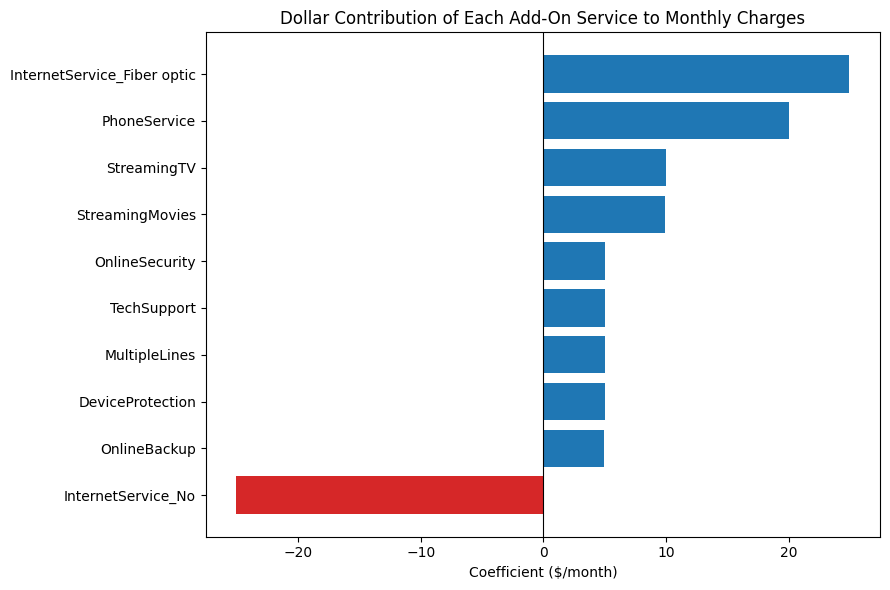

In [23]:
#Plot-1
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
colors = ['#d62728' if v < 0 else '#1f77b4' for v in coef_table['Coefficient ($/month)']]
plt.barh(coef_table['Service'], coef_table['Coefficient ($/month)'], color=colors)
plt.xlabel('Coefficient ($/month)')
plt.title('Dollar Contribution of Each Add-On Service to Monthly Charges')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('coefficient_chart.png', dpi=150)
plt.show()

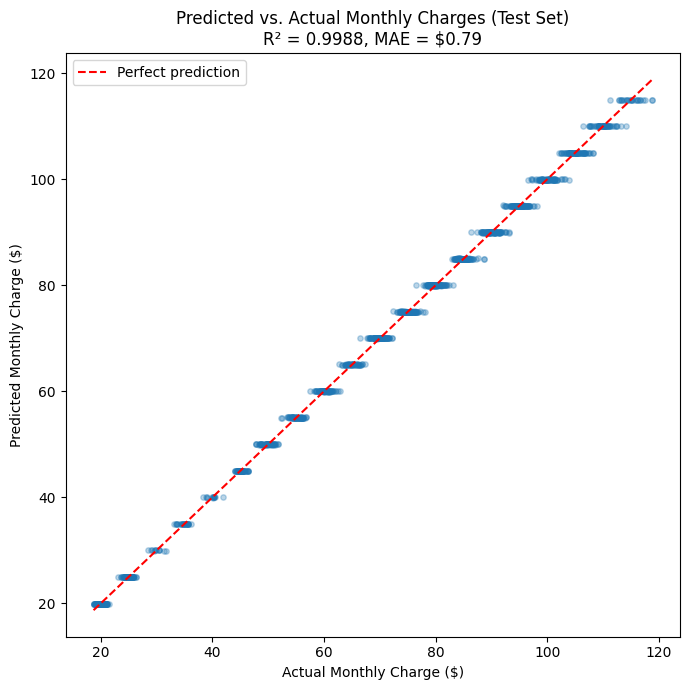

In [24]:
#Plot-2
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, s=15)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Monthly Charge ($)')
plt.ylabel('Predicted Monthly Charge ($)')
plt.title(f'Predicted vs. Actual Monthly Charges (Test Set)\nR² = {r2:.4f}, MAE = ${mae:.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()